# FORUM correlations

This notebook treats FORUM as an outcome of a ranking policy and asks where it agrees or disagrees with other summaries of the same ranking. The main plots are ranking-level plots: a point is a policy × outcome × interface/depth combination, with FORUM and nDCG averaged over stories. This avoids treating millions of comment rows as independent observations.

Questions:

1. Do top-10 and full-list FORUM agree across all rankings?
2. Does FORUM agree with nDCG across all rankings?
3. Do feature-level FORUM values from the regression rankings align with regression coefficients for the audience and editor selectors?
4. How does ML feature attribution (SHAP) align with FORUM?

SHAP is calculated and persisted by Stage 9 from the exact frozen winners. This notebook only aligns the story-aggregated SHAP summaries with the canonical ranking-level FORUM values and produces the comparison plots.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'commentgap_analysis').exists() and (REPO_ROOT.parent / 'commentgap_analysis').exists():
    REPO_ROOT = REPO_ROOT.parent
REPORTING_ROOT = REPO_ROOT / 'model_output/selection_2025/forum_ranking_analysis/reporting'
REPORTING_ROOT.mkdir(parents=True, exist_ok=True)

PAPER1_TABLES = REPO_ROOT / 'model_output/selection_2025/paper1/reporting/tables'
FORUM_ANALYSIS_INFERENCE = REPO_ROOT / 'model_output/selection_2025/forum_ranking_analysis/inference'
FORUM_ANALYSIS_SCORES = REPO_ROOT / 'model_output/selection_2025/forum_ranking_analysis/policy_scores/policy_scores.parquet'
REGRESSION_ROOT = REPO_ROOT / 'model_output/selection_2025/regression/all'

from commentgap_analysis.presentation_labels import (
    ORDERING_DISPLAY_LABELS, model_selector_label,
    OUTCOME_DISPLAY_LABELS, OUTCOME_DISPLAY_ORDER,
    REPLY_DISPLAY_MARKERS,
)
from commentgap_analysis.forum_plotting import (
    plot_forum_ndcg,
    plot_ml_forum_shap,
    plot_regression_forum_coefficients,
    plot_top10_full_forum,
)

FEATURE_LABELS = {
    **OUTCOME_DISPLAY_LABELS,
    'lexdiv_length_adjusted': 'Lexical diversity (adjusted)',
}
CORRELATION_EXCLUDED_OUTCOMES = {'lexdiv_length_adjusted'}

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

## 1. Load canonical ranking-level products

`policy_summary.csv` supplies the canonical story-averaged FORUM estimates. The policy-score parquet is used to obtain the matching story-averaged nDCG values. We keep the primary sample and retain all ordering, reply-mode, pinning, and depth combinations.

In [2]:
import json
from commentgap_analysis.forum_scores import FORUM_ANALYSIS_VERSION
for manifest_path in (
    FORUM_ANALYSIS_INFERENCE / 'inference_manifest.json',
    FORUM_ANALYSIS_SCORES.parent / 'policy_score_manifest.json',
):
    if not manifest_path.exists() or json.loads(manifest_path.read_text()).get('version') != FORUM_ANALYSIS_VERSION:
        raise RuntimeError('Stale pin/reply semantics. Rerun notebook 10 before notebook 12.')

policy_summary = pd.read_csv(FORUM_ANALYSIS_INFERENCE / 'policy_summary.csv')
policy_summary = policy_summary[policy_summary['sample'].eq('primary')].copy()
policy_summary['feature_label'] = policy_summary['outcome'].map(FEATURE_LABELS).fillna(policy_summary['outcome'])

score_columns = [
    'story_id', 'policy_id', 'ordering', 'reply_mode', 'pinned', 'deployable',
    'outcome', 'outcome_role', 'depth', 'forum', 'ndcg'
]
policy_scores = pd.read_parquet(FORUM_ANALYSIS_SCORES, columns=score_columns)
# outcome_role distinguishes the AQuA secondary outcome within the score product;
# it is still included in the primary-sample policy summary and belongs in the
# all-feature comparison requested here.

ranking_metrics = (
    policy_scores
    .groupby(['policy_id', 'ordering', 'reply_mode', 'pinned', 'deployable', 'outcome', 'depth'], as_index=False)
    .agg(forum=('forum', 'mean'), ndcg=('ndcg', 'mean'), n_stories=('story_id', 'nunique'))
)
ranking_metrics['feature_label'] = ranking_metrics['outcome'].map(FEATURE_LABELS).fillna(ranking_metrics['outcome'])
ranking_metrics['ordering_label'] = ranking_metrics['ordering'].map(ORDERING_DISPLAY_LABELS).fillna(ranking_metrics['ordering'])

# Check that the independent aggregation reproduces the published FORUM estimate.
check = policy_summary.merge(
    ranking_metrics,
    on=['policy_id', 'ordering', 'reply_mode', 'pinned', 'deployable', 'outcome', 'depth'],
    suffixes=('_published', '_recomputed'),
)
check['absolute_difference'] = (check['estimate'] - check['forum']).abs()
display(check['absolute_difference'].describe().to_frame('published_vs_recomputed_abs_difference'))
display(ranking_metrics.head())
print(f'{len(ranking_metrics):,} ranking-level rows; {ranking_metrics["ordering"].nunique()} orderings; {ranking_metrics["outcome"].nunique()} features.')

,published_vs_recomputed_abs_difference
count,8.280000e+03
mean,1.960951e-16
std,2.701427e-16
min,0.000000e+00
25%,4.510281e-17
50%,1.110223e-16
75%,2.220446e-16
max,3.441691e-15


,policy_id,ordering,reply_mode,pinned,deployable,outcome,depth,forum,ndcg,n_stories,feature_label,ordering_label
0,chronological__hidden__pinned,chronological,hidden,True,True,aqua_additional_knowledge_expected,full,0.106901,0.823626,2556,aqua_additional_knowledge_expected,Chronological
1,chronological__hidden__pinned,chronological,hidden,True,True,aqua_additional_knowledge_expected,top10,0.130941,0.435017,2556,aqua_additional_knowledge_expected,Chronological
2,chronological__hidden__pinned,chronological,hidden,True,True,aqua_discrimination_expected,full,0.072178,0.932258,2556,aqua_discrimination_expected,Chronological
3,chronological__hidden__pinned,chronological,hidden,True,True,aqua_discrimination_expected,top10,0.135850,0.677193,2556,aqua_discrimination_expected,Chronological
4,chronological__hidden__pinned,chronological,hidden,True,True,aqua_fact_expected,full,0.116973,0.928976,2556,aqua_fact_expected,Chronological


8,280 ranking-level rows; 15 orderings; 46 features.


## Correlation and outlier helpers

Pearson correlation captures linear agreement; Spearman correlation captures agreement in ranking order. The outlier tables use the absolute vertical distance from the reference line or, for FORUM–nDCG, a robust residual from a within-panel linear fit. Labels are intended as a short-list for inspection, not as an automatic substantive classification.

In [3]:
def correlation_row(frame, x, y, group_name='overall'):
    d = frame[[x, y]].dropna()
    if len(d) < 3 or d[x].nunique() < 2 or d[y].nunique() < 2:
        return {'group': group_name, 'n': len(d), 'pearson_r': np.nan, 'spearman_rho': np.nan}
    return {
        'group': group_name,
        'n': len(d),
        'pearson_r': d[x].corr(d[y], method='pearson'),
        'spearman_rho': d[x].corr(d[y], method='spearman'),
    }

def correlations_by(frame, x, y, group_cols):
    group_by = group_cols[0] if len(group_cols) == 1 else group_cols
    rows = [correlation_row(frame.loc[idx], x, y, ' | '.join(map(str, key if isinstance(key, tuple) else (key,))))
             for key, idx in frame.groupby(group_by, dropna=False).groups.items()]
    return pd.DataFrame(rows).sort_values('group').reset_index(drop=True)



## 2. Top-10 versus full-list FORUM

Each point is a ranking condition and feature. Colour denotes the feature, marker shape denotes reply handling, and filled versus hollow markers denote pinning status. Large departures from the dashed identity line are the first FORUM-behaviour outliers to inspect.

{'group': 'overall',
 'n': 4050,
 'pearson_r': np.float64(0.753742556999084),
 'spearman_rho': np.float64(0.8085364117255136)}

,group,n,pearson_r,spearman_rho
0,AQuA deliberative quality,90,0.810954,0.867177
1,Author incumbency,90,0.453097,0.623328
2,Author’s prior reception,90,0.591206,0.481236
3,Comment novelty,90,0.791308,0.872840
4,Comment-Article similarity,90,0.864504,0.895263
5,Lexical diversity,90,0.825842,0.880644
6,Negative sentiment,90,0.769071,0.820060
7,Positive sentiment,90,0.351509,0.445973
8,Reading difficulty,90,0.788054,0.863144
9,Toxicity,90,0.769504,0.811960


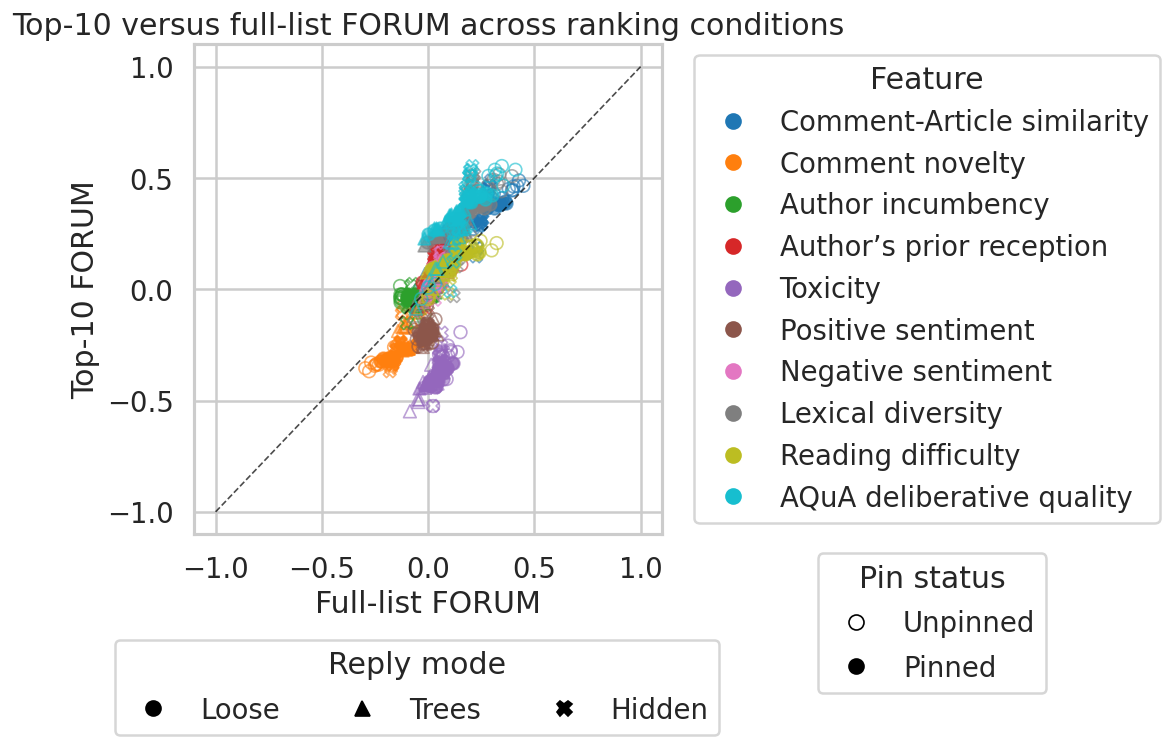

Largest top-10/full departures:


depth,feature_label,ordering,reply_mode,pinned,forum_top10,forum_full,difference_top10_minus_full
716,url_present,neural_metadata_editor,loose,False,-0.636600,0.401609,-1.038209
1256,url_present,neural_metadata_text_editor,loose,False,-0.706058,0.305187,-1.011245
2607,vienna_overnight,reverse_chronological,loose,False,-0.598891,0.384417,-0.983307
161,discussion_pace,chronological,loose,False,-0.753642,0.218847,-0.972489
671,url_present,neural_metadata_editor,loose,True,-0.678586,0.265688,-0.944274
446,url_present,neural_metadata_audience,loose,False,-0.866263,0.051864,-0.918127
1211,url_present,neural_metadata_text_editor,loose,True,-0.712097,0.199334,-0.911432
986,url_present,neural_metadata_text_audience,loose,False,-0.865372,0.034308,-0.899681
2562,vienna_overnight,reverse_chronological,loose,True,-0.691124,0.206286,-0.897409
3416,url_present,xgb_metadata_editor,loose,False,-0.773233,0.089843,-0.863076


In [4]:
forum_wide = (
    ranking_metrics[~ranking_metrics['outcome'].isin(CORRELATION_EXCLUDED_OUTCOMES)]
    .pivot_table(index=['policy_id', 'ordering', 'reply_mode', 'pinned', 'deployable', 'outcome', 'feature_label'],
                 columns='depth', values='forum', aggfunc='first')
    .reset_index()
)
forum_wide = forum_wide.rename(columns={'full': 'forum_full', 'top10': 'forum_top10'})
forum_wide = forum_wide.dropna(subset=['forum_full', 'forum_top10']).copy()
forum_wide['difference_top10_minus_full'] = forum_wide['forum_top10'] - forum_wide['forum_full']
forum_wide['abs_difference'] = forum_wide['difference_top10_minus_full'].abs()

display(correlation_row(forum_wide, 'forum_full', 'forum_top10'))
display(correlations_by(forum_wide, 'forum_full', 'forum_top10', ['feature_label']))

feature_order = [FEATURE_LABELS[outcome] for outcome in OUTCOME_DISPLAY_ORDER if FEATURE_LABELS[outcome] in forum_wide['feature_label'].unique()]
feature_palette = dict(zip(feature_order, sns.color_palette('tab10', len(feature_order))))
reply_markers = REPLY_DISPLAY_MARKERS
reply_labels = {'loose': 'Loose', 'trees': 'Trees', 'hidden': 'Hidden'}
top10_full_forum_figure = plot_top10_full_forum(
    forum_wide, feature_order, feature_palette, reply_markers, reply_labels,
    show=True,
)
top10_full_forum_figure.savefig(
    REPORTING_ROOT / 'forum_top10_full_across_ranking_conditions.pdf',
    bbox_inches='tight',
)
plt.close(top10_full_forum_figure)

print('Largest top-10/full departures:')
display(forum_wide.nlargest(20, 'abs_difference')[['feature_label', 'ordering', 'reply_mode', 'pinned', 'forum_top10', 'forum_full', 'difference_top10_minus_full']])

## 3. FORUM versus nDCG

This uses the same ranking-level units as the previous section. Separate top-10 and full-list figures make it possible to see whether apparent agreement is specific to the displayed top 10 or persists over the full visible list.

{'group': 'overall',
 'n': 8100,
 'pearson_r': np.float64(0.5845174054353479),
 'spearman_rho': np.float64(0.5098555978159233)}

,group,n,pearson_r,spearman_rho
0,full | AQuA deliberative quality,90,0.932684,0.959353
1,full | Author incumbency,90,0.916431,0.874585
2,full | Author’s prior reception,90,0.806969,0.773865
3,full | Comment novelty,90,0.940069,0.956472
4,full | Comment-Article similarity,90,0.973735,0.978862
...,...,...,...,...
85,top10 | reply_depth_centered,90,0.930185,0.993382
86,top10 | url_present,90,0.996365,0.996938
87,top10 | vienna_overnight,90,0.780760,0.787628
88,top10 | vienna_weekday_shoulder_evening,90,0.620742,0.584212


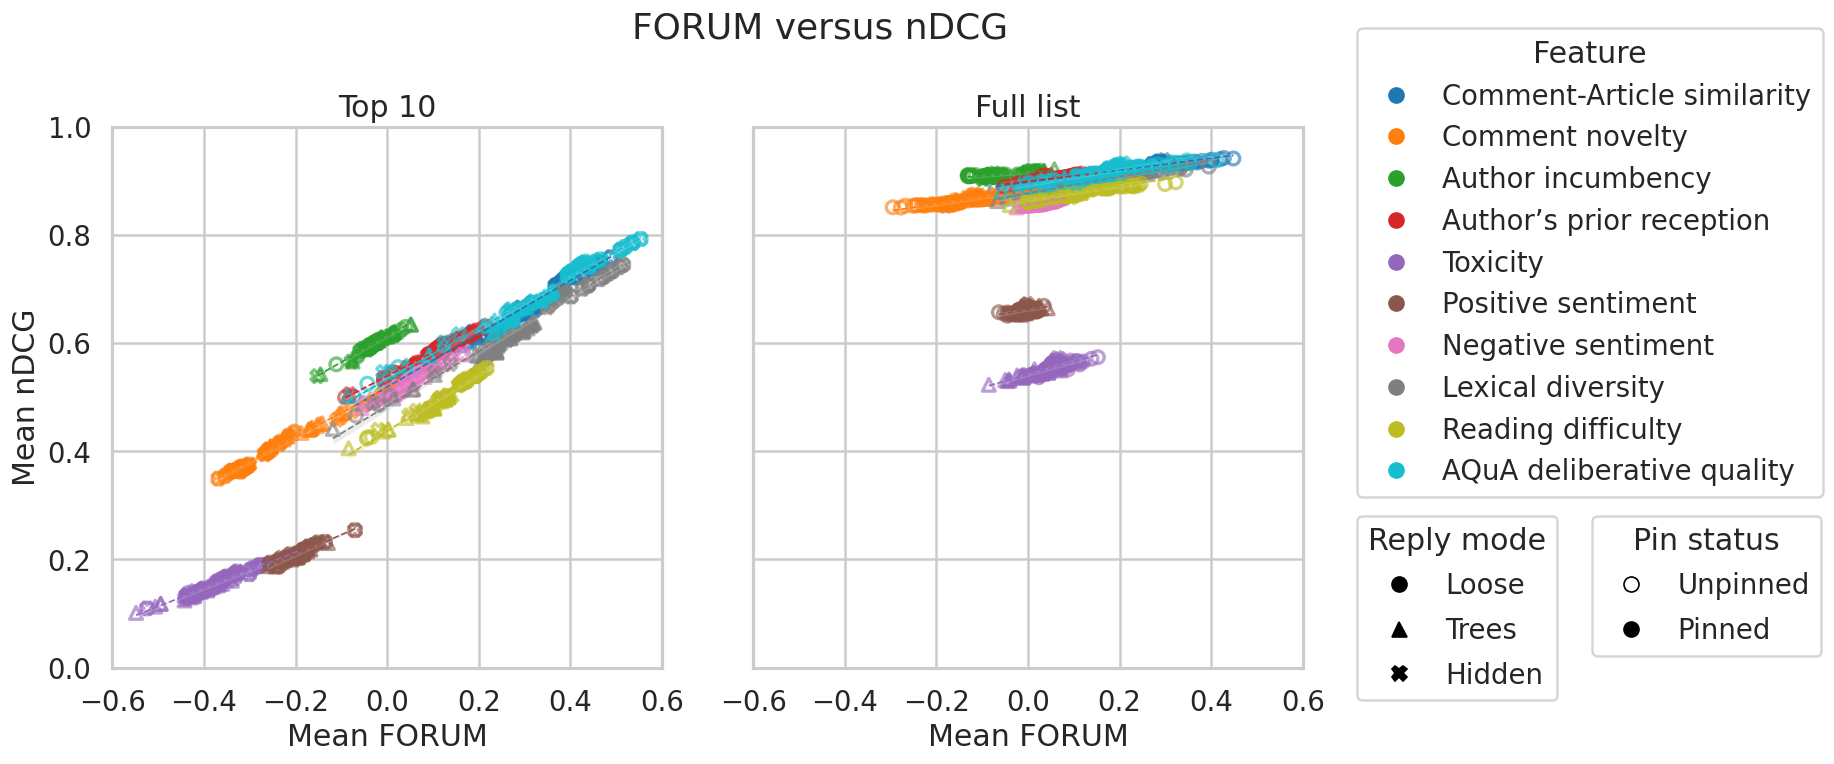

Largest within-depth FORUM/nDCG residuals:


,depth,feature_label,ordering,reply_mode,pinned,forum,ndcg,abs_residual
1464,full,url_present,neural_metadata_editor,loose,False,0.401609,0.377760,0.508117
2568,full,url_present,neural_metadata_text_editor,loose,False,0.305187,0.363556,0.500515
1372,full,url_present,neural_metadata_editor,loose,True,0.265688,0.369143,0.485996
2476,full,url_present,neural_metadata_text_editor,loose,True,0.199334,0.357623,0.482510
912,full,url_present,neural_metadata_audience,loose,False,0.051864,0.325481,0.481302
2016,full,url_present,neural_metadata_text_audience,loose,False,0.034308,0.322833,0.479980
6984,full,url_present,xgb_metadata_editor,loose,False,0.089843,0.342157,0.473215
6432,full,url_present,xgb_metadata_audience,loose,False,0.033607,0.331345,0.471309
7536,full,url_present,xgb_metadata_text_audience,loose,False,0.046759,0.335510,0.470118
8088,full,url_present,xgb_metadata_text_editor,loose,False,0.052721,0.338963,0.468014


In [5]:
forum_ndcg = ranking_metrics[~ranking_metrics['outcome'].isin(CORRELATION_EXCLUDED_OUTCOMES)].copy()
display(correlation_row(forum_ndcg, 'forum', 'ndcg'))
display(correlations_by(forum_ndcg, 'forum', 'ndcg', ['depth', 'feature_label']))

feature_order = [FEATURE_LABELS[outcome] for outcome in OUTCOME_DISPLAY_ORDER if FEATURE_LABELS[outcome] in forum_ndcg['feature_label'].unique()]
feature_palette = dict(zip(feature_order, sns.color_palette('tab10', len(feature_order))))
reply_markers = REPLY_DISPLAY_MARKERS
reply_labels = {'loose': 'Loose', 'trees': 'Trees', 'hidden': 'Hidden'}
forum_ndcg_figure = plot_forum_ndcg(
    forum_ndcg, feature_order, feature_palette, reply_markers, reply_labels,
    show=True,
)
forum_ndcg_figure.savefig(
    REPORTING_ROOT / 'forum_vs_ndcg_by_depth.pdf',
    bbox_inches='tight',
)
plt.close(forum_ndcg_figure)

print('Largest within-depth FORUM/nDCG residuals:')
outlier_parts = []
for depth, panel in forum_ndcg.groupby('depth'):
    panel = panel.copy()
    slope, intercept = np.polyfit(panel['forum'], panel['ndcg'], 1)
    panel['abs_residual'] = (panel['ndcg'] - (intercept + slope * panel['forum'])).abs()
    outlier_parts.append(panel)
display(pd.concat(outlier_parts).nlargest(20, 'abs_residual')[['depth', 'feature_label', 'ordering', 'reply_mode', 'pinned', 'forum', 'ndcg', 'abs_residual']])

## 4. Regression FORUM on feature versus coefficient

Here `x` is the story-averaged FORUM of a regression audience/editor ranking on the feature outcome, and `y` is the corresponding regression coefficient. The canonical interface is loose, unpinned; top-10 and full-list values are shown separately.

The selected FORUM/ranking analysis run no longer carries all 41 regression features. This diagnostic therefore plots only selected outcomes with matching coefficient rows and explicitly reports the remaining selected outcomes as unmatched.

Matched outcome features: 41
Unmatched policy outcomes: ['aqua_score_expected', 'author_prior_30d_reception_balance', 'cttr', 'semantic_novelty_knn5', 'smog_de']


,outcome,feature_label,selector,depth,forum,coefficient
0,aqua_additional_knowledge_expected,AQuA Additional knowledge is contributed (raw ...,audience,full,0.177896,-0.046828
2,aqua_discrimination_expected,AQuA Discriminatory language (raw expected ord...,audience,full,0.165385,0.062442
4,aqua_fact_expected,AQuA At least one factual claim (raw expected ...,audience,full,0.227717,0.093907
6,aqua_insult_expected,AQuA Insult or personal attack (raw expected o...,audience,full,0.130440,0.044046
8,aqua_justification_expected,AQuA A statement is justified (raw expected or...,audience,full,0.250588,0.115728
...,...,...,...,...,...,...
155,toxicity_probability,Maximum toxicity probability,editor,top10,-0.437697,-0.133283
157,url_present,URL present,editor,top10,-0.683650,0.428235
159,vienna_overnight,Overnight posting period,editor,top10,-0.680812,0.170024
161,vienna_weekday_shoulder_evening,Weekday shoulder/evening,editor,top10,-0.375360,0.223149


,group,n,pearson_r,spearman_rho
0,full | audience,41,0.628849,0.384495
1,full | editor,41,0.643931,0.401568
2,top10 | audience,41,0.403478,0.400523
3,top10 | editor,41,0.414327,0.306272


Odds-ratio correlations (including Spearman rank correlation):


,group,n,pearson_r,spearman_rho
0,full | audience,41,0.374223,0.384495
1,full | editor,41,0.565756,0.401568
2,top10 | audience,41,0.240131,0.400523
3,top10 | editor,41,0.342812,0.306272


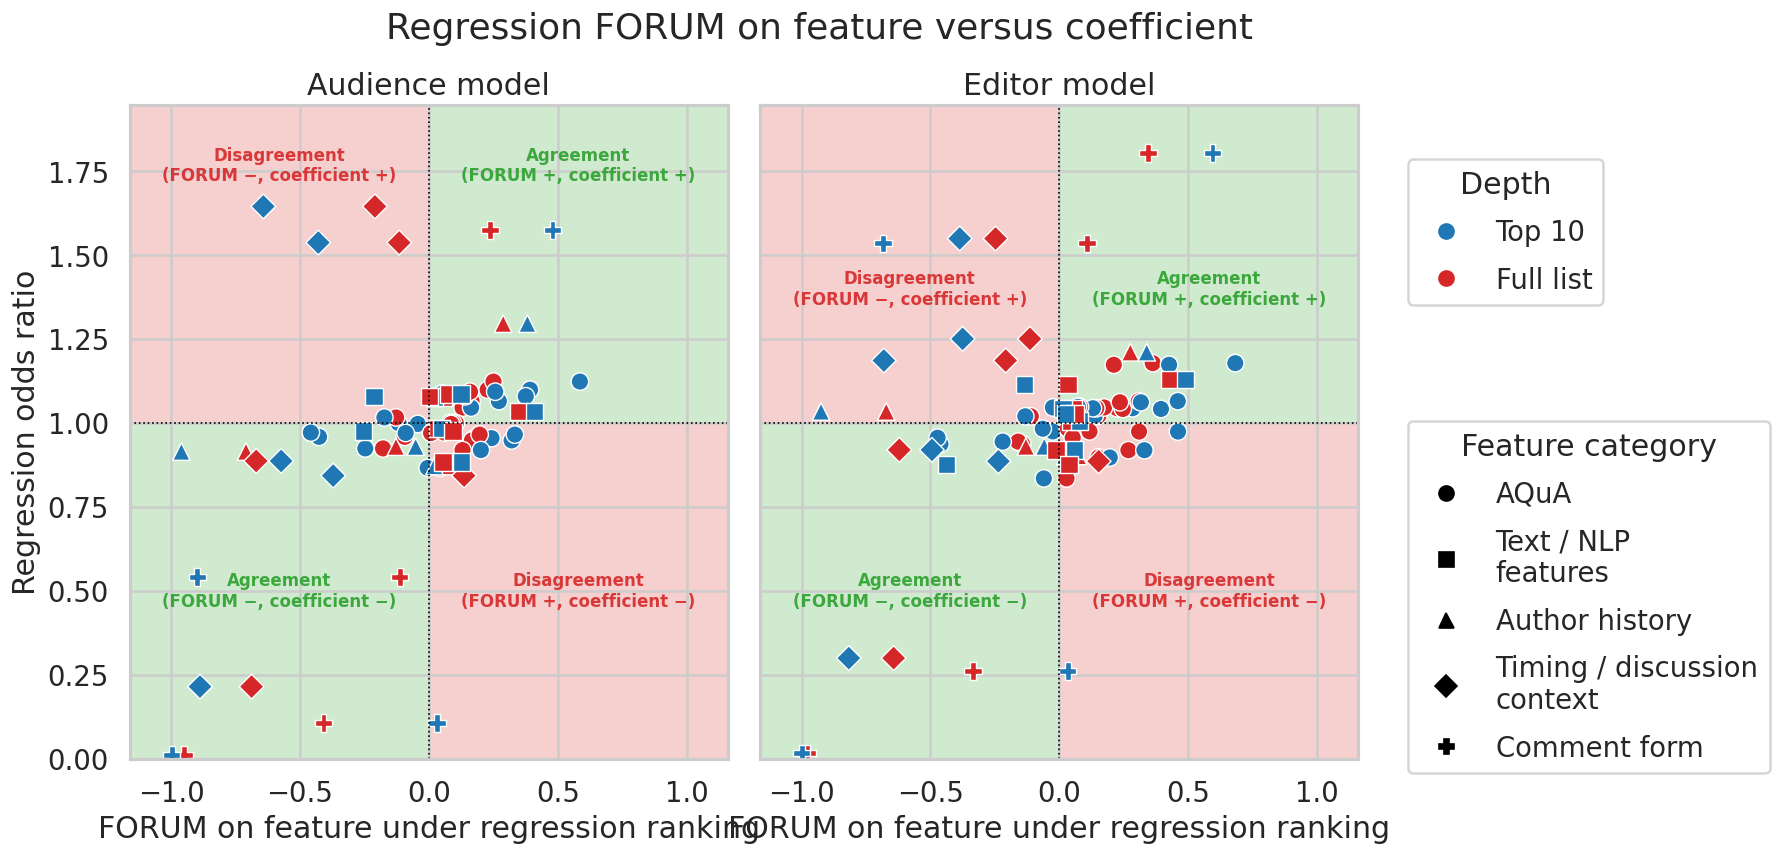

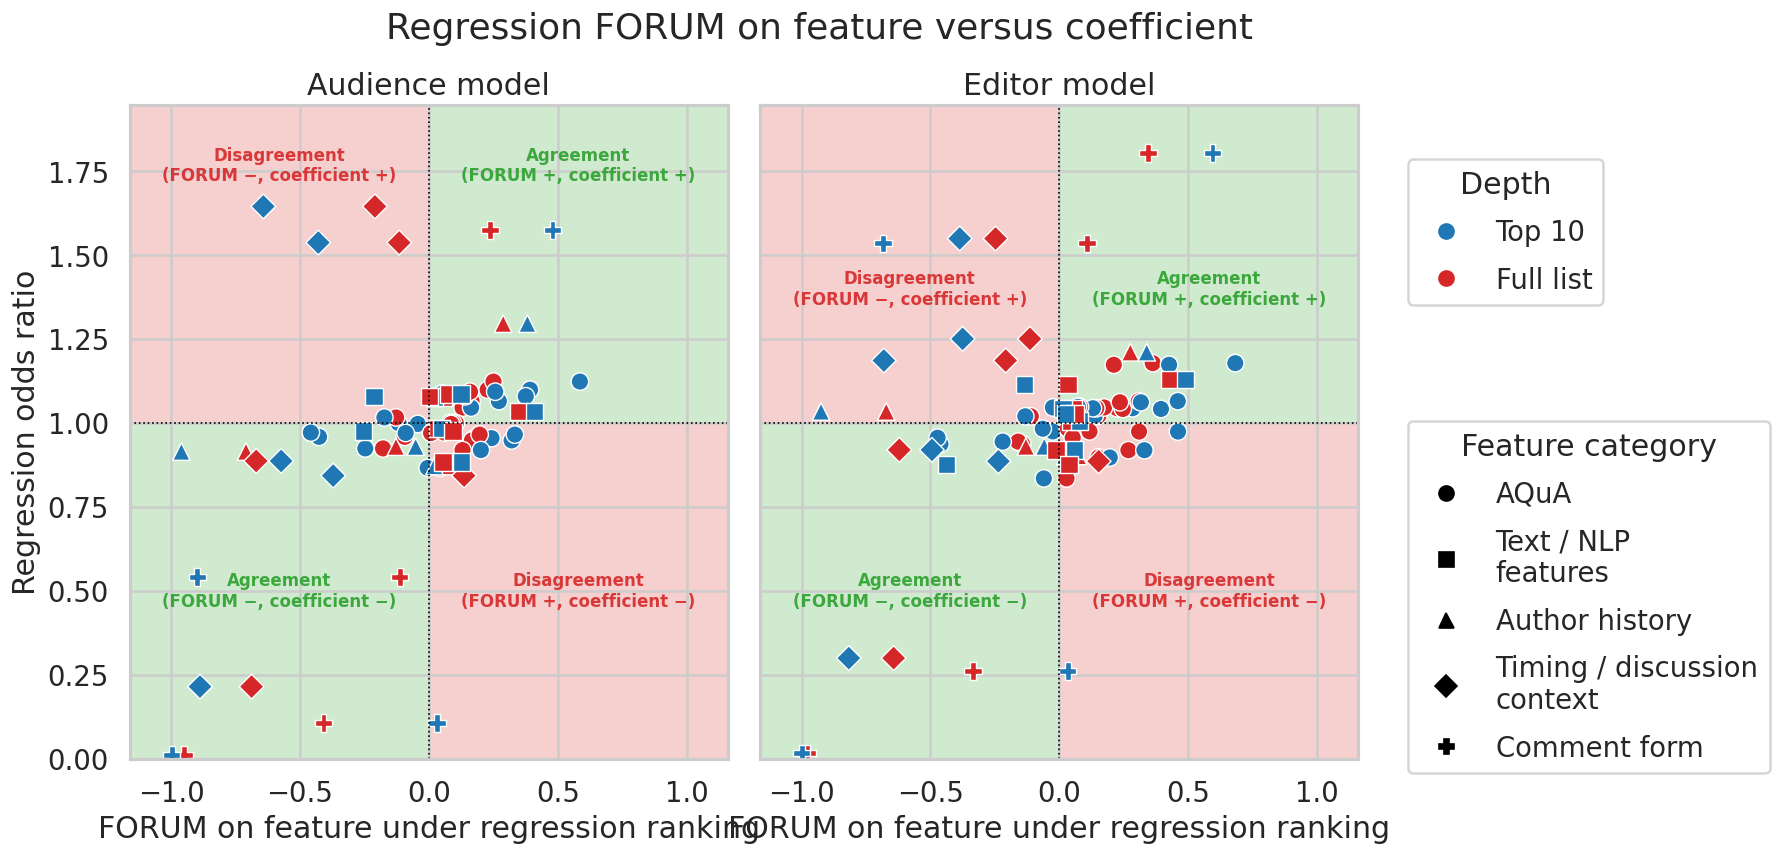

In [6]:
regression_coefficients = pd.read_csv(PAPER1_TABLES / 'regression_selector_associations.csv')
regression_coefficients = regression_coefficients[regression_coefficients['scope'].eq('all')].copy()

selector_map = {
    'audience': ('audience_log_odds', 'regression_audience'),
    'editor': ('curator_log_odds', 'regression_editor'),
}
coefficient_long = pd.concat([
    regression_coefficients[['term', 'feature', 'audience_log_odds']].rename(columns={'term': 'outcome', 'audience_log_odds': 'coefficient'}).assign(selector='audience', ordering='regression_audience'),
    regression_coefficients[['term', 'feature', 'curator_log_odds']].rename(columns={'term': 'outcome', 'curator_log_odds': 'coefficient'}).assign(selector='editor', ordering='regression_editor'),
], ignore_index=True)

regression_forum = ranking_metrics.query(
    "ordering in ['regression_audience', 'regression_editor'] and reply_mode == 'loose' and not pinned"
)[['ordering', 'outcome', 'depth', 'forum', 'feature_label']].copy()
regression_plot = regression_forum.merge(coefficient_long, on=['ordering', 'outcome'], how='inner')
regression_plot['feature_label'] = regression_plot['feature'].where(regression_plot['feature'].notna(), regression_plot['feature_label'])

def regression_feature_category(feature):
    feature = str(feature)
    lower = feature.lower()
    if feature.startswith('AQuA '):
        return 'AQuA'
    if 'earlier reply-to-root composition' in lower:
        return 'Timing / discussion\ncontext'
    if 'comment length' in lower or any(term in lower for term in ('url', 'reply', 'root')):
        return 'Comment form'
    if any(term in lower for term in ('length', 'lexical diversity', 'reading difficulty', 'sentiment', 'toxicity', 'similarity', 'novelty')):
        return 'Text / NLP\nfeatures'
    if 'author' in lower or 'prior author' in lower:
        return 'Author history'
    return 'Timing / discussion\ncontext'

regression_plot['feature_category'] = regression_plot['feature'].map(regression_feature_category)
regression_plot['odds_ratio'] = np.exp(regression_plot['coefficient'])

matched = sorted(regression_plot['outcome'].unique())
outcomes_without_coefficients = sorted(set(FEATURE_LABELS) - set(matched))
print(f'Matched outcome features: {len(matched)}')
print('Unmatched policy outcomes:', outcomes_without_coefficients)
display(regression_plot[['outcome', 'feature_label', 'selector', 'depth', 'forum', 'coefficient']].sort_values(['depth', 'selector', 'outcome']))

display(correlations_by(regression_plot, 'forum', 'coefficient', ['depth', 'selector']))
odds_ratio_correlations = correlations_by(regression_plot, 'forum', 'odds_ratio', ['depth', 'selector'])
print('Odds-ratio correlations (including Spearman rank correlation):')
display(odds_ratio_correlations)
plot_regression_forum_coefficients(regression_plot)

## 5. ML FORUM versus SHAP

Stage 9 calculates SHAP on the sealed `paper2_test` comments using a development-only background. The exported summary averages signed comment attributions within story and then averages stories, matching the FORUM estimand. The `metadata_bge` feature set is labelled as metadata + text, with all BGE dimensions summed into one `text_bge` block. Mean absolute SHAP remains available as an importance diagnostic, but the comparisons below use signed mean SHAP contributions.

,group,n,pearson_r,spearman_rho
0,neural | metadata | audience | full,41,0.557870,0.338328
1,neural | metadata | audience | top10,41,0.497741,0.453833
2,neural | metadata | curator | full,41,0.594330,0.166551
3,neural | metadata | curator | top10,41,0.518042,0.309756
4,neural | metadata_bge | audience | full,41,0.566533,0.395819
5,neural | metadata_bge | audience | top10,41,0.462326,0.464111
6,neural | metadata_bge | curator | full,41,0.594870,0.251742
7,neural | metadata_bge | curator | top10,41,0.470439,0.322125
8,xgboost | metadata | audience | full,41,0.680572,0.480662
9,xgboost | metadata | audience | top10,41,0.482021,0.485192


,model_family,feature_set,selector,outcome,feature_label,depth,forum,n_policies,scope,model_id,...,mean_shap_gap_story_q75,story_count,story_lower_quantile,story_upper_quantile,model_family_label,shap_value,shap_gap,model_variant,model_kind,feature_category
0,neural,metadata,audience,aqua_additional_knowledge_expected,aqua_additional_knowledge_expected,full,0.220791,1,all,nn__metadata__draw1__random4__plateau__separat...,...,0.017592,2559.0,0.25,0.75,NN,0.035579,-0.000687,NN: Audience,NN,Timing / discussion\ncontext
2,neural,metadata,audience,aqua_discrimination_expected,aqua_discrimination_expected,full,0.155077,1,all,nn__metadata__draw1__random4__plateau__separat...,...,0.027198,2559.0,0.25,0.75,NN,0.030820,-0.007367,NN: Audience,NN,Timing / discussion\ncontext
4,neural,metadata,audience,aqua_fact_expected,aqua_fact_expected,full,0.251599,1,all,nn__metadata__draw1__random4__plateau__separat...,...,0.025430,2559.0,0.25,0.75,NN,0.041908,0.005824,NN: Audience,NN,Timing / discussion\ncontext
6,neural,metadata,audience,aqua_insult_expected,aqua_insult_expected,full,0.122556,1,all,nn__metadata__draw1__random4__plateau__separat...,...,0.038403,2559.0,0.25,0.75,NN,0.011172,0.018464,NN: Audience,NN,Timing / discussion\ncontext
8,neural,metadata,audience,aqua_justification_expected,aqua_justification_expected,full,0.241914,1,all,nn__metadata__draw1__random4__plateau__separat...,...,0.040557,2559.0,0.25,0.75,NN,0.021808,0.015100,NN: Audience,NN,Timing / discussion\ncontext
10,neural,metadata,audience,aqua_opinion_expected,aqua_opinion_expected,full,0.071023,1,all,nn__metadata__draw1__random4__plateau__separat...,...,0.067590,2559.0,0.25,0.75,NN,0.019945,0.008035,NN: Audience,NN,Timing / discussion\ncontext
12,neural,metadata,audience,aqua_polite_address_expected,aqua_polite_address_expected,full,0.118587,1,all,nn__metadata__draw1__random4__plateau__separat...,...,0.011654,2559.0,0.25,0.75,NN,0.002540,0.002303,NN: Audience,NN,Timing / discussion\ncontext
14,neural,metadata,audience,aqua_question_expected,aqua_question_expected,full,-0.055983,1,all,nn__metadata__draw1__random4__plateau__separat...,...,0.025679,2559.0,0.25,0.75,NN,0.036538,0.006345,NN: Audience,NN,Timing / discussion\ncontext
16,neural,metadata,audience,aqua_referencing_contents_expected,aqua_referencing_contents_expected,full,-0.153110,1,all,nn__metadata__draw1__random4__plateau__separat...,...,0.017929,2559.0,0.25,0.75,NN,-0.012290,0.004075,NN: Audience,NN,Timing / discussion\ncontext
18,neural,metadata,audience,aqua_referencing_format_expected,aqua_referencing_format_expected,full,0.124358,1,all,nn__metadata__draw1__random4__plateau__separat...,...,0.029684,2559.0,0.25,0.75,NN,0.019865,0.005597,NN: Audience,NN,Timing / discussion\ncontext


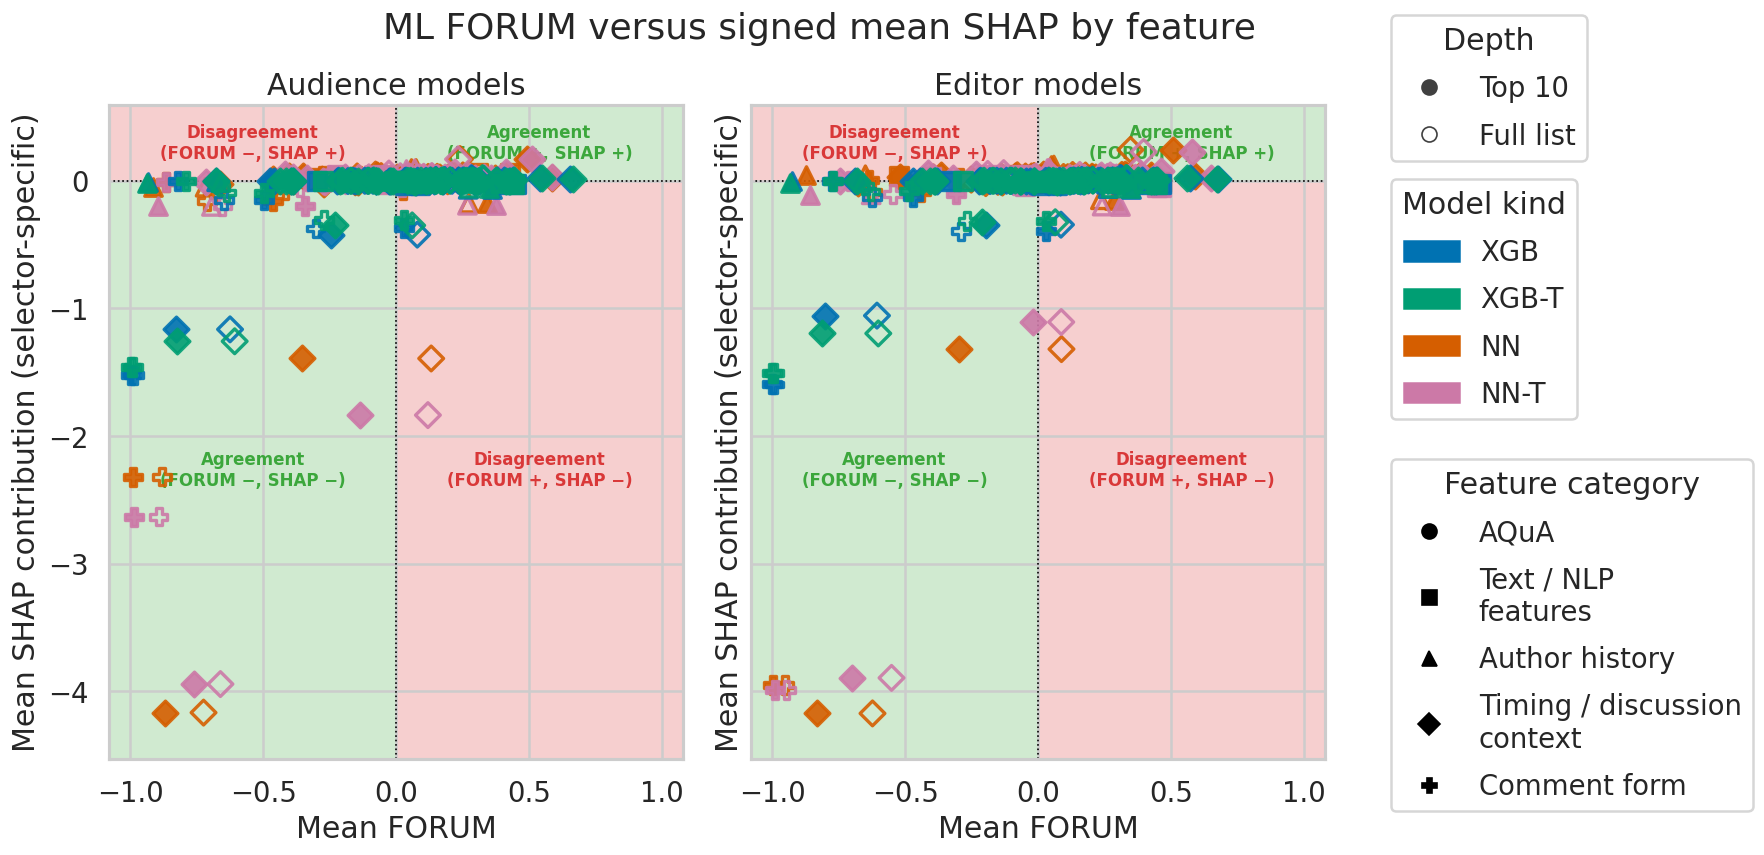

,group,n,pearson_r,spearman_rho
0,neural | metadata | full,41,0.231540,0.083972
1,neural | metadata | top10,41,0.027852,0.019861
2,neural | metadata_bge | full,41,0.108537,0.251742
3,neural | metadata_bge | top10,41,0.168201,0.118467
4,xgboost | metadata | full,41,0.163391,0.230354
5,xgboost | metadata | top10,41,0.407269,0.361735
6,xgboost | metadata_bge | full,41,0.379924,0.388530
7,xgboost | metadata_bge | top10,41,0.365849,0.517113


In [7]:
SHAP_SUMMARY = PAPER1_TABLES / 'held_out_shap_importance.parquet'
if not SHAP_SUMMARY.exists():
    raise FileNotFoundError(f'Run notebook 09 before this section: {SHAP_SUMMARY}')

shap_summary = pd.read_parquet(SHAP_SUMMARY)
shap_summary = shap_summary[shap_summary['feature_group'].ne('selector')].copy() if 'feature_group' in shap_summary else shap_summary
shap_summary['model_family_label'] = shap_summary['model_family'].map({'xgboost': 'XGB', 'neural': 'NN'}).fillna(shap_summary['model_family'])

ml_orderings = [
    'xgb_metadata_audience', 'xgb_metadata_editor',
    'xgb_metadata_text_audience', 'xgb_metadata_text_editor',
    'neural_metadata_audience', 'neural_metadata_editor',
    'neural_metadata_text_audience', 'neural_metadata_text_editor',
]
ml_forum = ranking_metrics.query(
    "ordering in @ml_orderings and reply_mode == 'loose' and not pinned"
).copy()
ml_forum['model_family'] = np.where(ml_forum['ordering'].str.startswith('xgb'), 'xgboost', 'neural')
ml_forum['feature_set'] = np.where(ml_forum['ordering'].str.contains('text'), 'metadata_bge', 'metadata')
ml_forum['selector'] = np.where(ml_forum['ordering'].str.contains('audience'), 'audience', 'curator')
ml_forum = ml_forum.groupby(['model_family', 'feature_set', 'selector', 'outcome', 'feature_label', 'depth'], as_index=False).agg(
    forum=('forum', 'mean'), n_policies=('policy_id', 'nunique')
)

ml_shap_forum = ml_forum.merge(
    shap_summary,
    left_on=['model_family', 'feature_set', 'outcome'],
    right_on=['model_family', 'feature_set', 'feature'],
    how='inner',
    suffixes=('', '_shap'),
)
if ml_shap_forum.empty:
    raise RuntimeError('No ML FORUM rows matched the Stage 9 SHAP summary')
ml_shap_forum['shap_value'] = np.where(ml_shap_forum['selector'].eq('audience'), ml_shap_forum['mean_shap_audience'], ml_shap_forum['mean_shap_curator'])
ml_shap_forum['shap_gap'] = ml_shap_forum['mean_shap_gap']
ml_shap_forum['model_variant'] = ml_shap_forum.apply(
    lambda row: model_selector_label(row['model_family'], row['feature_set'], row['selector']),
    axis=1,
)
ml_shap_forum['model_kind'] = ml_shap_forum['model_variant'].str.split(':').str[0]
ml_shap_forum['feature_category'] = ml_shap_forum['feature_label'].map(regression_feature_category)
display(correlations_by(ml_shap_forum, 'forum', 'shap_value', ['model_family', 'feature_set', 'selector', 'depth']))
display(ml_shap_forum.sort_values(['model_family', 'feature_set', 'selector', 'depth', 'outcome']).head(30))

plot_ml_forum_shap(ml_shap_forum)

forum_gap = ml_forum.pivot_table(
    index=['model_family', 'feature_set', 'outcome', 'feature_label', 'depth'],
    columns='selector', values='forum', aggfunc='first'
).reset_index()
forum_gap = forum_gap.rename(columns={'audience': 'forum_audience', 'curator': 'forum_curator'})
forum_gap['forum_gap'] = forum_gap['forum_curator'] - forum_gap['forum_audience']
gap_panel = forum_gap.merge(
    shap_summary,
    left_on=['model_family', 'feature_set', 'outcome'],
    right_on=['model_family', 'feature_set', 'feature'],
    how='inner',
)
display(correlations_by(gap_panel, 'forum_gap', 'mean_shap_gap', ['model_family', 'feature_set', 'depth']))

## Interpretation checklist

When reviewing the plots, prioritise points that are far from the relevant reference pattern, but keep the aggregation and design in view. A high correlation does not imply that FORUM and nDCG are interchangeable; the scientifically interesting cases are ranking conditions where one metric is high and the other is unexpectedly low, or where the top-10/full-list relationship changes sharply by feature.

### Paper reporting: 84 substantive policies and ten primary outcomes

The diagnostics above include random controls and additional features. The paper uses the explicitly filtered statistics and figures below.

In [ ]:
# Paper reporting uses a narrower scope than the exploratory diagnostics above.
# Use current version-4 scores, never the legacy paper2/policy_scores directory.
from commentgap_analysis.forum_scores import PRIMARY_OUTCOMES

paper_metrics = ranking_metrics[
    ranking_metrics['deployable']
    & ranking_metrics['outcome'].isin(PRIMARY_OUTCOMES)
].copy()
assert paper_metrics['policy_id'].nunique() == 84
assert paper_metrics['outcome'].nunique() == 10
assert paper_metrics.groupby('depth').size().eq(840).all()
paper_wide = paper_metrics.pivot(
    index=['policy_id', 'ordering', 'reply_mode', 'pinned', 'outcome', 'feature_label'],
    columns='depth', values='forum',
).reset_index().rename(columns={'full': 'forum_full', 'top10': 'forum_top10'})
paper_correlations = pd.DataFrame([
    correlation_row(paper_wide, 'forum_full', 'forum_top10', 'top10_vs_full'),
    *[correlation_row(panel, 'forum', 'ndcg', f'forum_vs_ndcg_{depth}')
      for depth, panel in paper_metrics.groupby('depth')],
])
paper_feature_correlations = pd.concat([
    correlations_by(paper_wide, 'forum_full', 'forum_top10', ['feature_label'])
        .assign(comparison='top10_vs_full'),
    correlations_by(paper_metrics, 'forum', 'ndcg', ['depth', 'feature_label'])
        .assign(comparison='forum_vs_ndcg'),
], ignore_index=True)
print('Paper scope: 84 substantive policies × 10 primary outcomes; 840 points per depth.')
display(paper_correlations)
display(paper_feature_correlations)
paper_correlations.to_csv(REPORTING_ROOT / 'paper_primary_correlations.csv', index=False)
paper_feature_correlations.to_csv(REPORTING_ROOT / 'paper_primary_feature_correlations.csv', index=False)

paper_feature_order = [FEATURE_LABELS[outcome] for outcome in OUTCOME_DISPLAY_ORDER]
paper_palette = dict(zip(paper_feature_order, sns.color_palette('tab10', len(paper_feature_order))))
paper_reply_labels = {'loose': 'Loose', 'trees': 'Trees', 'hidden': 'Hidden'}
for paper_plot, paper_frame, paper_filename in [
    (plot_top10_full_forum, paper_wide, 'paper_forum_top10_full_across_ranking_conditions.pdf'),
    (plot_forum_ndcg, paper_metrics, 'paper_forum_vs_ndcg_by_depth.pdf'),
]:
    paper_figure = paper_plot(
        paper_frame, paper_feature_order, paper_palette,
        REPLY_DISPLAY_MARKERS, paper_reply_labels, show=True,
    )
    paper_figure.savefig(REPORTING_ROOT / paper_filename, bbox_inches='tight')
    plt.close(paper_figure)


Paper scope: 84 substantive policies × 10 primary outcomes; 840 points per depth.
              group   n  pearson_r  spearman_rho
      top10_vs_full 840   0.772551      0.811400
 forum_vs_ndcg_full 840   0.262433      0.537611
forum_vs_ndcg_top10 840   0.901357      0.895070
                             group  n  pearson_r  spearman_rho    comparison
         AQuA deliberative quality 84   0.804741      0.862144 top10_vs_full
                 Author incumbency 84   0.433963      0.602875 top10_vs_full
          Author’s prior reception 84   0.539399      0.372077 top10_vs_full
                   Comment novelty 84   0.789846      0.872289 top10_vs_full
        Comment-Article similarity 84   0.870064      0.893692 top10_vs_full
                 Lexical diversity 84   0.821497      0.877189 top10_vs_full
                Negative sentiment 84   0.762801      0.804313 top10_vs_full
                Positive sentiment 84   0.364500      0.475914 top10_vs_full
                Reading diffi